In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

In [2]:
csv_path = "/home/madhulika.gurazada/paper2/Data/Total_crop_areas_year_mean/crop_areas_hd.csv"
crop_areas_hd = pd.read_csv(csv_path)
crop_areas_hd

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean
0,djf,1,7.652567e+07,5.277759e+07,3.374928e+07,4.941819e+07,1.792676e+08,5.747188e+07
1,djf,2,2.884565e+07,5.277759e+07,2.902945e+07,4.941819e+07,2.877493e+07,5.747188e+07
2,djf,3,1.746509e+07,5.277759e+07,2.045223e+07,4.941819e+07,1.433423e+07,5.747188e+07
3,djf,4,2.117387e+07,5.277759e+07,2.799610e+07,4.941819e+07,4.575859e+07,5.747188e+07
4,djf,5,4.940859e+07,5.277759e+07,1.317601e+07,4.941819e+07,7.472327e+07,5.747188e+07
...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,7.086228e+07,8.173884e+07
299,son1,47,NaN,NaN,NaN,NaN,6.036429e+07,8.173884e+07
300,son1,48,NaN,NaN,NaN,NaN,1.617843e+08,8.173884e+07
301,son1,49,NaN,NaN,NaN,NaN,2.735348e+07,8.173884e+07


In [3]:
# ENSO years
el_years = [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]
la_years = [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]
ne_years = [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]

In [4]:
# 3. Build mapping dicts
el_map = {i+1: yr for i, yr in enumerate(el_years)}
la_map = {i+1: yr for i, yr in enumerate(la_years)}
ne_map = {i+1: yr for i, yr in enumerate(ne_years)}

# 4. Map into new columns
crop_areas_hd['el_year'] = crop_areas_hd['year_index'].map(el_map)
crop_areas_hd['la_year'] = crop_areas_hd['year_index'].map(la_map)
crop_areas_hd['ne_year'] = crop_areas_hd['year_index'].map(ne_map)

crop_areas_hd

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean,el_year,la_year,ne_year
0,djf,1,7.652567e+07,5.277759e+07,3.374928e+07,4.941819e+07,1.792676e+08,5.747188e+07,1902.0,1903.0,1901
1,djf,2,2.884565e+07,5.277759e+07,2.902945e+07,4.941819e+07,2.877493e+07,5.747188e+07,1904.0,1908.0,1906
2,djf,3,1.746509e+07,5.277759e+07,2.045223e+07,4.941819e+07,1.433423e+07,5.747188e+07,1905.0,1909.0,1907
3,djf,4,2.117387e+07,5.277759e+07,2.799610e+07,4.941819e+07,4.575859e+07,5.747188e+07,1911.0,1910.0,1912
4,djf,5,4.940859e+07,5.277759e+07,1.317601e+07,4.941819e+07,7.472327e+07,5.747188e+07,1913.0,1916.0,1915
...,...,...,...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,7.086228e+07,8.173884e+07,NaN,NaN,2001
299,son1,47,NaN,NaN,NaN,NaN,6.036429e+07,8.173884e+07,NaN,NaN,2003
300,son1,48,NaN,NaN,NaN,NaN,1.617843e+08,8.173884e+07,NaN,NaN,2004
301,son1,49,NaN,NaN,NaN,NaN,2.735348e+07,8.173884e+07,NaN,NaN,2012


In [5]:
# 2. Define the desired season order
season_order = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# 3. Convert 'season' to an ordered categorical
crop_areas_hd['season'] = pd.Categorical(crop_areas_hd['season'], categories=season_order, ordered=True)

# 4. Sort by season (and optionally year_index)
crop_areas_hd = crop_areas_hd.sort_values(['season', 'year_index']).reset_index(drop=True)

crop_areas_hd

,season,year_index,el,el_mean,la,la_mean,ne,ne_mean,el_year,la_year,ne_year
0,jja,1,1.540410e+08,1.025042e+08,8.131407e+07,7.944123e+07,1.954181e+08,7.419431e+07,1902.0,1903.0,1901
1,jja,2,6.690215e+07,1.025042e+08,2.063658e+07,7.944123e+07,3.564706e+07,7.419431e+07,1904.0,1908.0,1906
2,jja,3,1.239310e+08,1.025042e+08,1.493092e+07,7.944123e+07,2.276772e+07,7.419431e+07,1905.0,1909.0,1907
3,jja,4,1.309367e+08,1.025042e+08,6.474418e+07,7.944123e+07,1.731810e+07,7.419431e+07,1911.0,1910.0,1912
4,jja,5,1.421954e+08,1.025042e+08,1.760661e+07,7.944123e+07,7.610767e+07,7.419431e+07,1913.0,1916.0,1915
...,...,...,...,...,...,...,...,...,...,...,...
298,son1,46,NaN,NaN,NaN,NaN,7.086228e+07,8.173884e+07,NaN,NaN,2001
299,son1,47,NaN,NaN,NaN,NaN,6.036429e+07,8.173884e+07,NaN,NaN,2003
300,son1,48,NaN,NaN,NaN,NaN,1.617843e+08,8.173884e+07,NaN,NaN,2004
301,son1,49,NaN,NaN,NaN,NaN,2.735348e+07,8.173884e+07,NaN,NaN,2012


In [6]:
crop_areas_hd_mean = (
    crop_areas_hd
    .groupby('season')[['el_mean', 'la_mean', 'ne_mean']]
    .mean()
    .reset_index()
)

crop_areas_hd_mean['el_minus_ne'] = crop_areas_hd_mean['el_mean'] - crop_areas_hd_mean['ne_mean']
crop_areas_hd_mean['la_minus_ne'] = crop_areas_hd_mean['la_mean'] - crop_areas_hd_mean['ne_mean']
crop_areas_hd_mean

,season,el_mean,la_mean,ne_mean,el_minus_ne,la_minus_ne
0,jja,1.025042e+08,7.944123e+07,7.419431e+07,2.830987e+07,5.246924e+06
1,son,8.377526e+07,7.929594e+07,7.090327e+07,1.287200e+07,8.392669e+06
2,djf,5.277759e+07,4.941819e+07,5.747188e+07,-4.694293e+06,-8.053694e+06
3,mam1,7.567303e+07,6.973739e+07,7.010825e+07,5.564773e+06,-3.708601e+05
4,jja1,8.865591e+07,8.221486e+07,8.240830e+07,6.247612e+06,-1.934443e+05
5,son1,7.506427e+07,7.575421e+07,8.173884e+07,-6.674571e+06,-5.984630e+06


In [7]:
results = []

for season in crop_areas_hd['season'].cat.categories:
    # select rows for this season
    df_season = crop_areas_hd[crop_areas_hd['season'] == season]
    
    # extract the per‐year series
    el = df_season['el'].dropna().values
    la = df_season['la'].dropna().values
    ne = df_season['ne'].dropna().values
    
    # Mann–Whitney U tests: two‐sided
    p_el_ne = mannwhitneyu(el, ne, alternative='two-sided').pvalue
    p_la_ne = mannwhitneyu(la, ne, alternative='two-sided').pvalue
    
    results.append({
        'season':    season,
        'n_el':      el.size,
        'n_la':      la.size,
        'n_ne':      ne.size,
        'p_el_vs_ne': p_el_ne,
        'p_la_vs_ne': p_la_ne
    })

sig_df = pd.DataFrame(results)
sig_df

,season,n_el,n_la,n_ne,p_el_vs_ne,p_la_vs_ne
0,jja,34,38,51,0.001428,0.413921
1,son,34,38,51,0.304363,0.325655
2,djf,34,38,51,0.464720,0.317556
3,mam1,34,37,50,0.300989,0.948659
4,jja1,34,37,50,0.532474,0.900928
5,son1,34,37,50,0.296750,0.677121


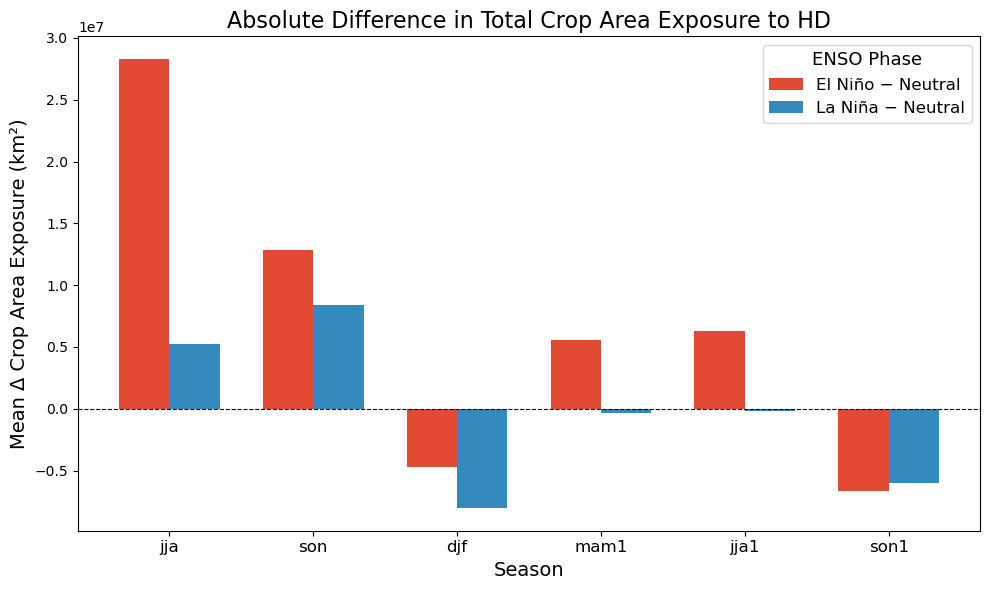

In [8]:
# X locations
x = np.arange(len(season_order))
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# El Niño vs Neutral
ax.bar(
    x - width/2,
    crop_areas_hd_mean['el_minus_ne'],
    width,
    label='El Niño − Neutral',
    color='#E24A33'
)

# La Niña vs Neutral
ax.bar(
    x + width/2,
    crop_areas_hd_mean['la_minus_ne'],
    width,
    label='La Niña − Neutral',
    color='#348ABD'
)

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('Mean Δ Crop Area Exposure (km²)', fontsize=14)
ax.set_title('Absolute Difference in Total Crop Area Exposure to HD', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Legend
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)

plt.tight_layout()
plt.show()


In [9]:
crop_areas_hd_mean['el_minus_ne_rel'] = (crop_areas_hd_mean['el_mean'] - crop_areas_hd_mean['ne_mean'])*100/crop_areas_hd_mean['ne_mean']
crop_areas_hd_mean['la_minus_ne_rel'] = (crop_areas_hd_mean['la_mean'] - crop_areas_hd_mean['ne_mean'])*100/crop_areas_hd_mean['ne_mean']
crop_areas_hd_mean

,season,el_mean,la_mean,ne_mean,el_minus_ne,la_minus_ne,el_minus_ne_rel,la_minus_ne_rel
0,jja,1.025042e+08,7.944123e+07,7.419431e+07,2.830987e+07,5.246924e+06,38.156392,7.071869
1,son,8.377526e+07,7.929594e+07,7.090327e+07,1.287200e+07,8.392669e+06,18.154306,11.836787
2,djf,5.277759e+07,4.941819e+07,5.747188e+07,-4.694293e+06,-8.053694e+06,-8.167981,-14.013277
3,mam1,7.567303e+07,6.973739e+07,7.010825e+07,5.564773e+06,-3.708601e+05,7.937401,-0.528982
4,jja1,8.865591e+07,8.221486e+07,8.240830e+07,6.247612e+06,-1.934443e+05,7.581289,-0.234739
5,son1,7.506427e+07,7.575421e+07,8.173884e+07,-6.674571e+06,-5.984630e+06,-8.165728,-7.321648


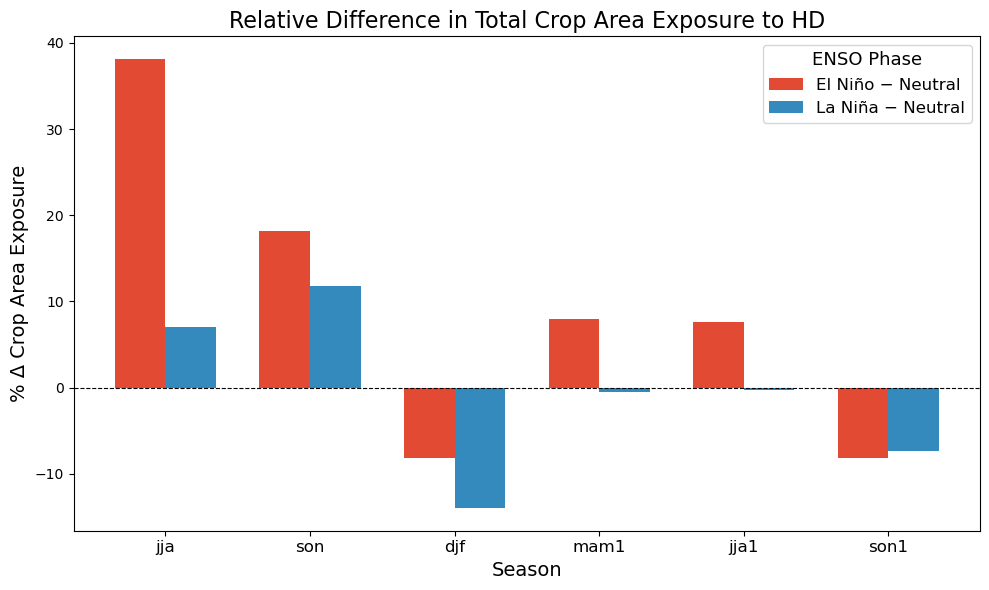

In [10]:
# X locations
x = np.arange(len(season_order))
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# El Niño vs Neutral
ax.bar(
    x - width/2,
    crop_areas_hd_mean['el_minus_ne_rel'],
    width,
    label='El Niño − Neutral',
    color='#E24A33'
)

# La Niña vs Neutral
ax.bar(
    x + width/2,
    crop_areas_hd_mean['la_minus_ne_rel'],
    width,
    label='La Niña − Neutral',
    color='#348ABD'
)

# Labels and title
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=14)
ax.set_title('Relative Difference in Total Crop Area Exposure to HD', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# Legend
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)

plt.tight_layout()
plt.show()

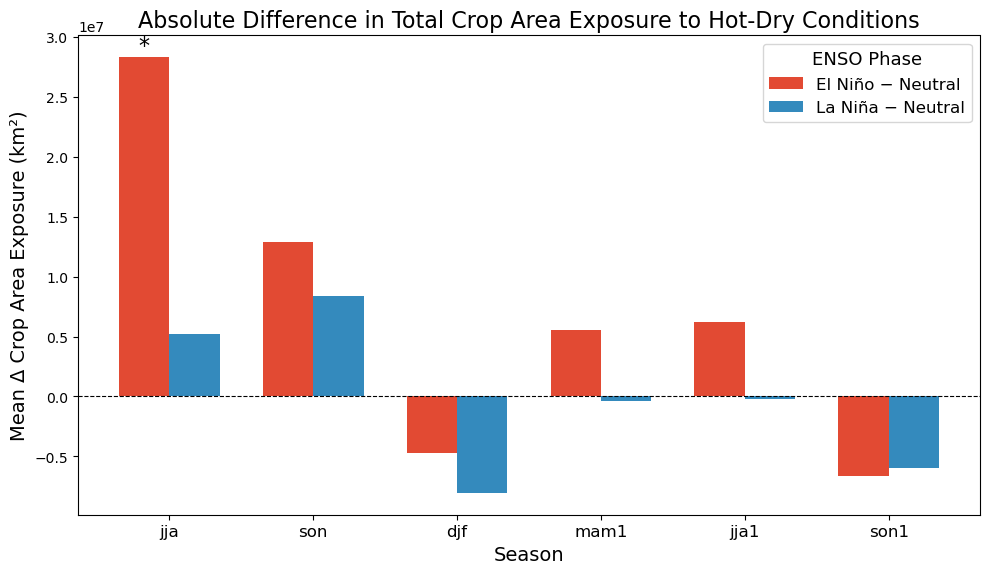

In [11]:
# 1. Prepare x locations and bar width
x = np.arange(len(season_order))
width = 0.35

# 2. Extract bar heights
el_vals = crop_areas_hd_mean['el_minus_ne'].values
la_vals = crop_areas_hd_mean['la_minus_ne'].values

# 3. Build the basic bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_vals, width, label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_vals, width, label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# choose a small offset above the tallest bar for the star
ymax = max(np.max(el_vals), np.max(la_vals))
offset = ymax * 0.001  #at some height above bar

for i, season in enumerate(season_order):
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]
    
    # El Niño star
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,     # x coordinate: center of the El Niño bar
            el_vals[i] + offset,  # y coordinate: top of bar + offset
            '*', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=16
        )
    # La Niña star
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_vals[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final plot tweaks
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('Mean Δ Crop Area Exposure (km²)', fontsize=14)
ax.set_title('Absolute Difference in Total Crop Area Exposure to Hot‑Dry Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)
plt.tight_layout()
plt.show()

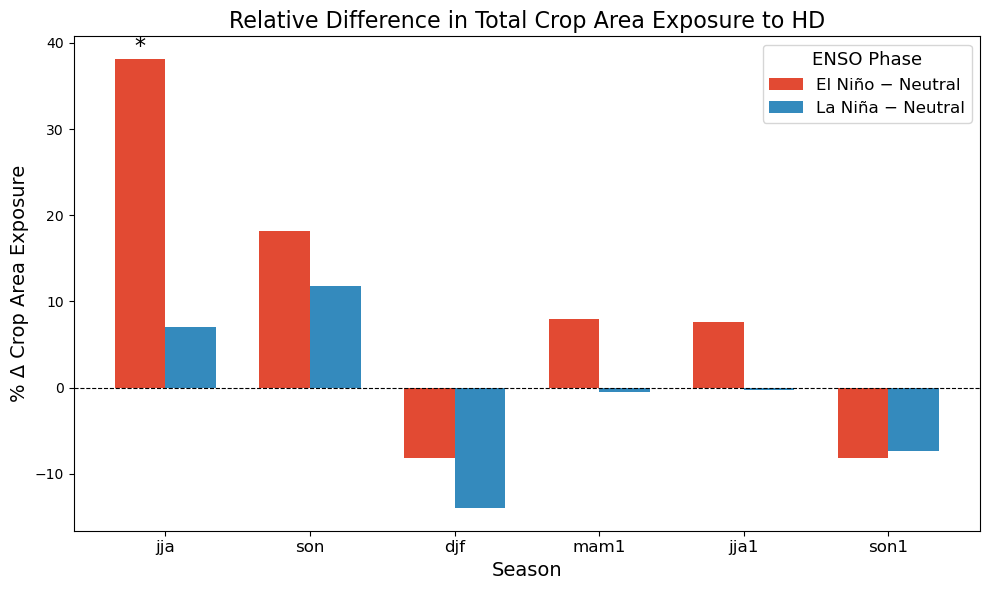

In [12]:
# 1. Prepare x locations and width
x = np.arange(len(season_order))
width = 0.35

# 2. Extract relative differences in the correct season order
el_rel = crop_areas_hd_mean['el_minus_ne_rel'].values
la_rel = crop_areas_hd_mean['la_minus_ne_rel'].values

# 3. Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_rel, width,
                 label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_rel, width,
                 label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# pick an offset as a small fraction of the tallest bar
ymax = max(el_rel.max(), la_rel.max())
offset = ymax * 0.001  # 0.1% of max bar height

for i, season in enumerate(season_order):
    # get p-values for this season
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]

    # annotate El Niño bar
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,
            el_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )
    # annotate La Niña bar
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final styling
ax.set_xticks(x)
ax.set_xticklabels(season_order, fontsize=12)
ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=14)
ax.set_title('Relative Difference in Total Crop Area Exposure to HD', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=12, title='ENSO Phase', title_fontsize=13)
plt.tight_layout()
plt.show()

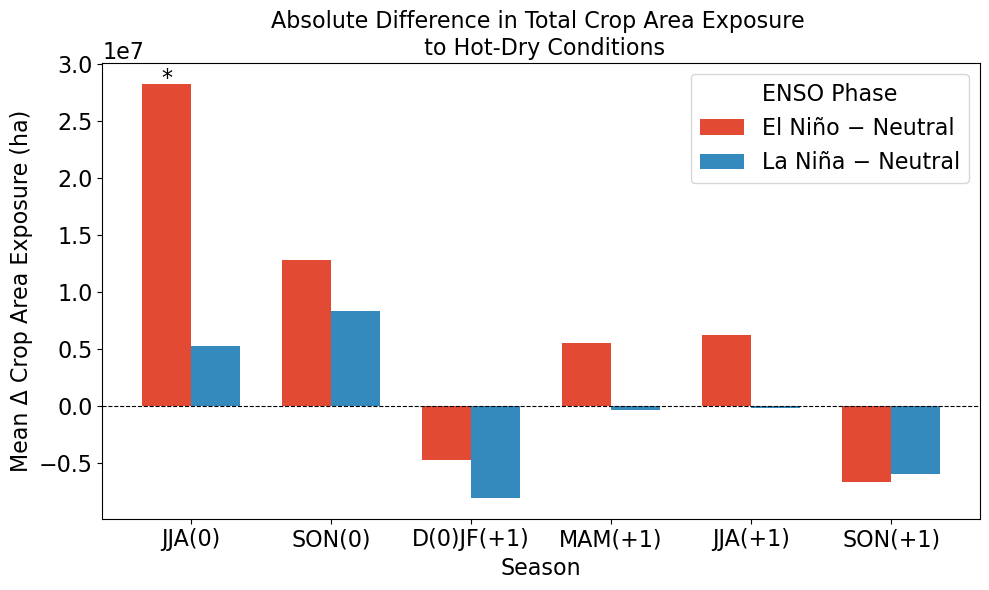

In [13]:
# 1. Prepare x locations and bar width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# 2. Extract bar heights
el_vals = crop_areas_hd_mean['el_minus_ne'].values
la_vals = crop_areas_hd_mean['la_minus_ne'].values

# 3. Build the basic bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_vals, width, label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_vals, width, label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# choose a small offset above the tallest bar for the star
ymax = max(np.max(el_vals), np.max(la_vals))
offset = ymax * -0.02  #at some height above bar

for i, season in enumerate(season_order):
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]
    
    # El Niño star
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,     # x coordinate: center of the El Niño bar
            el_vals[i] + offset,  # y coordinate: top of bar + offset
            '*', 
            ha='center', 
            va='bottom', 
            color='black', 
            fontsize=16
        )
    # La Niña star
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_vals[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final plot tweaks
ax.set_xticks(x)
ax.set_xticklabels(custom_labels, fontsize=16)
ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('Mean Δ Crop Area Exposure (ha)', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.yaxis.get_offset_text().set_fontsize(16)
ax.set_title('Absolute Difference in Total Crop Area Exposure \n to Hot‑Dry Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=16, title='ENSO Phase', title_fontsize=16)
plt.tight_layout()
plt.show()

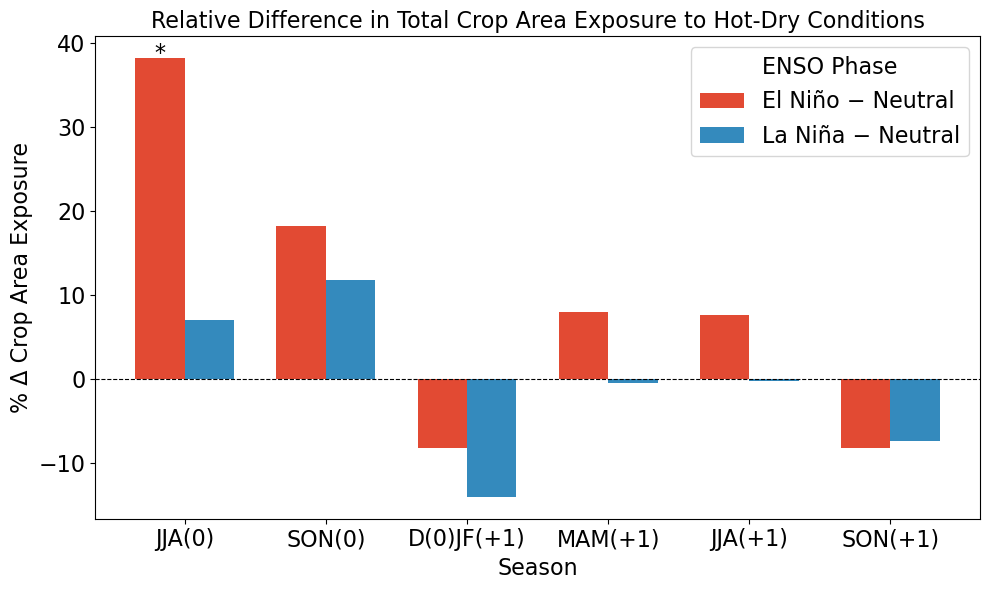

In [14]:
# 1. Prepare x locations and width
x = np.arange(len(season_order))
width = 0.35
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# 2. Extract relative differences in the correct season order
el_rel = crop_areas_hd_mean['el_minus_ne_rel'].values
la_rel = crop_areas_hd_mean['la_minus_ne_rel'].values

# 3. Create the bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars_el = ax.bar(x - width/2, el_rel, width,
                 label='El Niño − Neutral', color='#E24A33')
bars_la = ax.bar(x + width/2, la_rel, width,
                 label='La Niña − Neutral', color='#348ABD')

# 4. Add significance stars
# pick an offset as a small fraction of the tallest bar
ymax = max(el_rel.max(), la_rel.max())
offset = ymax * -0.02  # 0.1% of max bar height

for i, season in enumerate(season_order):
    # get p-values for this season
    p_el = sig_df.loc[sig_df['season'] == season, 'p_el_vs_ne'].values[0]
    p_la = sig_df.loc[sig_df['season'] == season, 'p_la_vs_ne'].values[0]

    # annotate El Niño bar
    if p_el < 0.05:
        ax.text(
            x[i] - width/2,
            el_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )
    # annotate La Niña bar
    if p_la < 0.05:
        ax.text(
            x[i] + width/2,
            la_rel[i] + offset,
            '*',
            ha='center',
            va='bottom',
            color='black',
            fontsize=16
        )

# 5. Final styling
ax.set_xticks(x)
ax.set_xticklabels(custom_labels, fontsize=16)
ax.set_xlabel('Season', fontsize=16)
ax.set_ylabel('% Δ Crop Area Exposure', fontsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.set_title('Relative Difference in Total Crop Area Exposure to Hot-Dry Conditions', fontsize=16)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=16, title='ENSO Phase', title_fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
crop_areas_hd_mean

,season,el_mean,la_mean,ne_mean,el_minus_ne,la_minus_ne,el_minus_ne_rel,la_minus_ne_rel
0,jja,1.025042e+08,7.944123e+07,7.419431e+07,2.830987e+07,5.246924e+06,38.156392,7.071869
1,son,8.377526e+07,7.929594e+07,7.090327e+07,1.287200e+07,8.392669e+06,18.154306,11.836787
2,djf,5.277759e+07,4.941819e+07,5.747188e+07,-4.694293e+06,-8.053694e+06,-8.167981,-14.013277
3,mam1,7.567303e+07,6.973739e+07,7.010825e+07,5.564773e+06,-3.708601e+05,7.937401,-0.528982
4,jja1,8.865591e+07,8.221486e+07,8.240830e+07,6.247612e+06,-1.934443e+05,7.581289,-0.234739
5,son1,7.506427e+07,7.575421e+07,8.173884e+07,-6.674571e+06,-5.984630e+06,-8.165728,-7.321648
